In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

In [2]:
df = pd.read_csv("customer_features.csv")
df.head()

,customer_unique_id,customer_city,customer_state,total_orders,repeat_customer,total_spent,average_order_value,median_order_value,minimum_order_value,maximum_order_value,...,recency,customer_lifetime_days,customer_age,weekend_purchase_percentage,average_item_price,freight_percentage,purchase_frequency,category_diversity_ratio,low_review_orders,high_review_orders
0,df3bcbcb88d40ad1996ad1325fe8f481,praia grande,SP,1,0,160.28,160.28,160.28,160.28,160.28,...,124,0,124,0.0,80.14,14.349888,inf,0.5,0,1
1,58704dbb44acbec0448a215ac2871320,sao paulo,SP,1,0,70.72,70.72,70.72,70.72,70.72,...,379,0,379,0.0,70.72,16.586538,inf,1.0,0,1
2,e06358b52b33afa8edfe5a0664cfe9c5,ponte serrada,SC,1,0,60.10,60.10,60.10,60.10,60.10,...,240,0,240,0.0,60.10,25.124792,inf,1.0,1,0
3,ee66c72bc9c41ae9de8260314b8088f4,juiz de fora,MG,1,0,247.36,247.36,247.36,247.36,247.36,...,119,0,119,0.0,123.68,19.154269,inf,0.5,0,1
4,c2e79de2c0a7751e26564a3917f9e86d,sao paulo,SP,1,0,115.44,115.44,115.44,115.44,115.44,...,504,0,504,0.0,115.44,13.383576,inf,1.0,0,1


In [3]:
print(df.shape)
df.info()
df.describe()

(96096, 39)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_unique_id           96096 non-null  object 
 1   customer_city                96096 non-null  object 
 2   customer_state               96096 non-null  object 
 3   total_orders                 96096 non-null  int64  
 4   repeat_customer              96096 non-null  int64  
 5   total_spent                  96095 non-null  float64
 6   average_order_value          96095 non-null  float64
 7   median_order_value           96095 non-null  float64
 8   minimum_order_value          96095 non-null  float64
 9   maximum_order_value          96095 non-null  float64
 10  spend_std_dev                2997 non-null   float64
 11  total_items                  96096 non-null  float64
 12  average_basket_size          96096 non-null  float64
 13  larg

C:\Users\swath\anaconda3\lib\site-packages\numpy\lib\function_base.py:4573: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,total_orders,repeat_customer,total_spent,average_order_value,median_order_value,minimum_order_value,maximum_order_value,spend_std_dev,total_items,average_basket_size,...,recency,customer_lifetime_days,customer_age,weekend_purchase_percentage,average_item_price,freight_percentage,purchase_frequency,category_diversity_ratio,low_review_orders,high_review_orders
count,96096.000000,96096.000000,96095.000000,96095.000000,96095.000000,96095.00000,96095.000000,2997.000000,96096.000000,96096.000000,...,96096.000000,96096.000000,96096.000000,96096.000000,95419.000000,95419.000000,9.605000e+04,95420.000000,96096.000000,96096.000000
mean,1.034809,0.031188,165.024963,159.886924,159.853582,158.43295,161.393656,64.579776,1.231165,1.183750,...,288.108797,2.722954,290.831752,22.967270,143.696040,23.555616,inf,0.918133,0.150360,0.791167
std,0.214384,0.173825,229.830686,220.708011,220.722834,220.24920,222.401962,110.751110,0.855688,0.718911,...,153.417869,25.445278,153.906664,41.849774,198.261239,50.637533,NaN,0.213566,0.364061,0.469953
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.185000,0.000000,3.284072e-03,0.000000,0.000000,0.000000
25%,1.000000,0.000000,62.330000,61.640000,61.620000,60.42000,61.825000,8.315576,1.000000,1.000000,...,164.000000,0.000000,166.000000,0.000000,55.586250,11.773604,NaN,1.000000,0.000000,1.000000
50%,1.000000,0.000000,106.900000,104.700000,104.630000,103.07000,105.380000,31.614744,1.000000,1.000000,...,269.000000,0.000000,272.000000,0.000000,94.220000,18.663704,NaN,1.000000,0.000000,1.000000
75%,1.000000,0.000000,181.860000,175.905000,175.870000,174.36000,177.560000,75.547289,1.000000,1.000000,...,397.000000,0.000000,401.000000,0.000000,161.040000,28.322180,NaN,1.000000,0.000000,1.000000
max,17.000000,1.000000,13664.080000,13664.080000,13664.080000,13664.08000,13664.080000,1646.887049,75.000000,38.000000,...,773.000000,633.000000,773.000000,100.000000,9553.020000,6405.405405,inf,1.000000,3.000000,16.000000


In [4]:
total_customers = df["customer_unique_id"].nunique()
total_orders = df["total_orders"].sum()
total_revenue = df["total_spent"].sum()
average_customer_spend = df["total_spent"].mean()
average_order_value = total_revenue / total_orders
average_review = df["average_review"].mean()
average_delivery_days = df["average_delivery_days"].mean()
average_delivery_delay = df["average_delivery_delay"].mean()
repeat_customers = (df["total_orders"] > 1).sum()
repeat_rate = repeat_customers / total_customers * 100

In [5]:
print("="*50)
print("BUSINESS KPIs")
print("="*50)
print(f"Total Customers        : {total_customers:,}")
print(f"Total Orders           : {total_orders:,}")
print(f"Total Revenue          : ${total_revenue:,.2f}")
print(f"Average Order Value    : ${average_order_value:.2f}")
print(f"Average Customer Spend : ${average_customer_spend:.2f}")
print(f"Average Review Score   : {average_review:.2f}")
print(f"Average Delivery Days  : {average_delivery_days:.2f}")
print(f"Average Delivery Delay : {average_delivery_delay:.2f} days")
print(f"Repeat Customer Rate   : {repeat_rate:.2f}%")

BUSINESS KPIs
Total Customers        : 96,096
Total Orders           : 99,441
Total Revenue          : $15,858,073.82
Average Order Value    : $159.47
Average Customer Spend : $165.02
Average Review Score   : 4.08
Average Delivery Days  : 12.51
Average Delivery Delay : -11.85 days
Repeat Customer Rate   : 3.12%


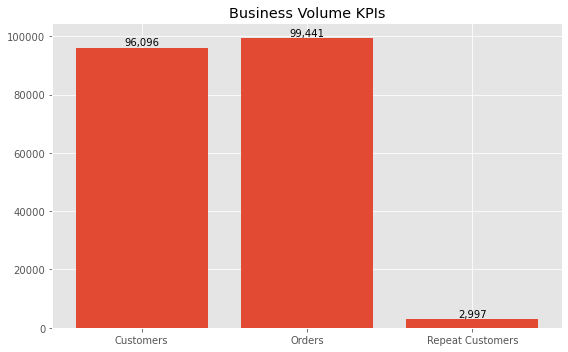

In [6]:
volume_values = [
    total_customers,
    total_orders,
    repeat_customers
]
volume_labels = [
    "Customers",
    "Orders",
    "Repeat Customers"
]
plt.figure(figsize=(8,5))
bars = plt.bar(volume_labels, volume_values)
plt.title("Business Volume KPIs")
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

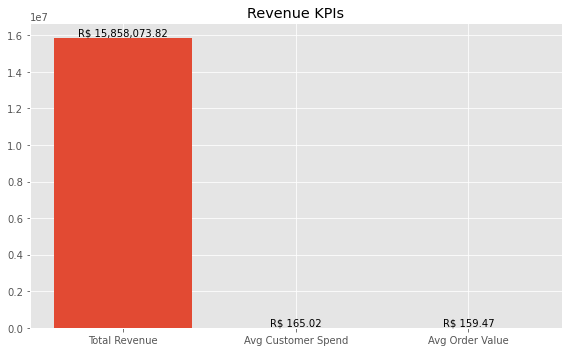

In [7]:
revenue_values = [
    total_revenue,
    average_customer_spend,
    average_order_value
]
revenue_labels = [
    "Total Revenue",
    "Avg Customer Spend",
    "Avg Order Value"
]
plt.figure(figsize=(8,5))
bars = plt.bar(revenue_labels, revenue_values)
plt.title("Revenue KPIs")
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"R$ {bar.get_height():,.2f}",
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.show()

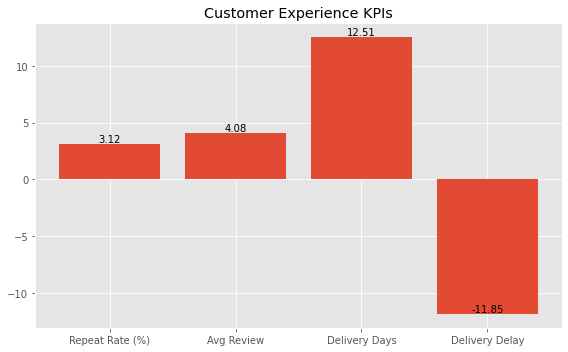

In [8]:
experience_values = [
    repeat_rate,
    average_review,
    average_delivery_days,
    average_delivery_delay
]
experience_labels = [
    "Repeat Rate (%)",
    "Avg Review",
    "Delivery Days",
    "Delivery Delay"
]
plt.figure(figsize=(8,5))
bars = plt.bar(experience_labels, experience_values)
plt.title("Customer Experience KPIs")
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )
plt.tight_layout()
plt.show()

In [9]:
#Additional KPI Charts

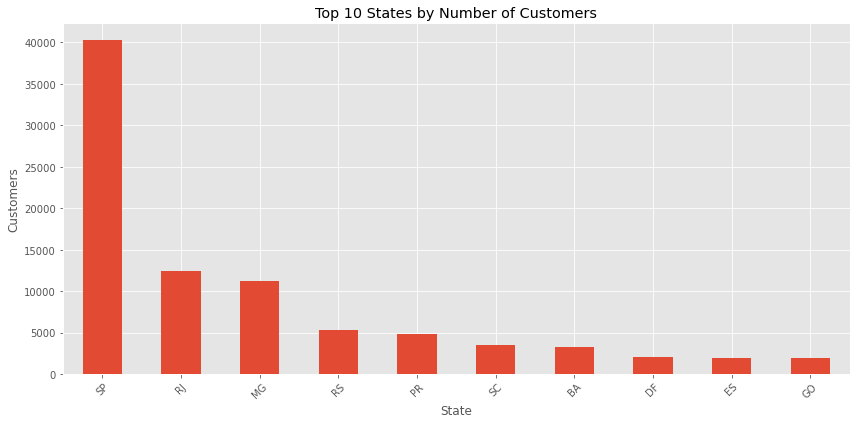

In [10]:
#Customer Distribution by State
plt.figure(figsize=(12,6))
state_counts = (
    df["customer_state"]
      .value_counts()
      .head(10)
)
state_counts.plot(kind="bar")
plt.title("Top 10 States by Number of Customers")
plt.xlabel("State")
plt.ylabel("Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

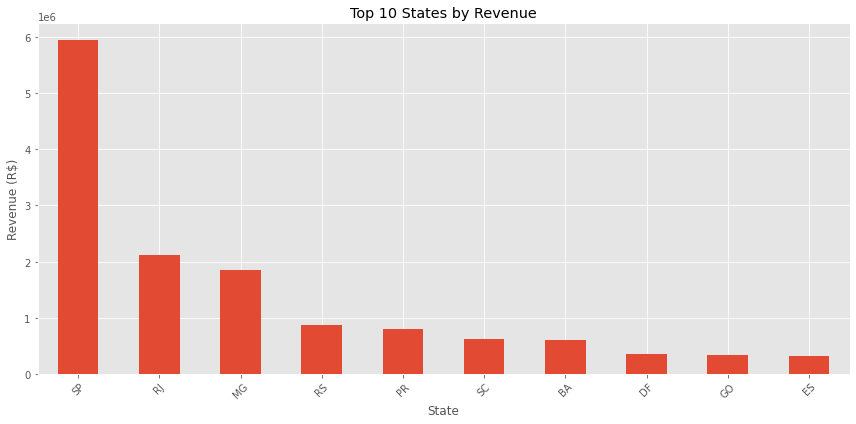

In [11]:
#Revenue by State
state_revenue = (
    df.groupby("customer_state")["total_spent"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
plt.figure(figsize=(12,6))
state_revenue.plot(kind="bar")
plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

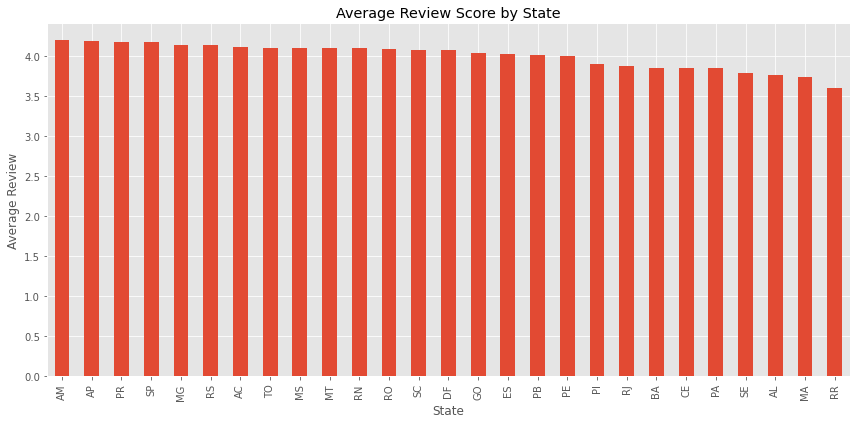

In [12]:
#Average Review Score by State
review_state = (
    df.groupby("customer_state")["average_review"]
      .mean()
      .sort_values(ascending=False)
)
plt.figure(figsize=(12,6))
review_state.plot(kind="bar")
plt.title("Average Review Score by State")
plt.xlabel("State")
plt.ylabel("Average Review")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

C:\Users\swath\AppData\Local\Temp\ipykernel_10396\3710144397.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


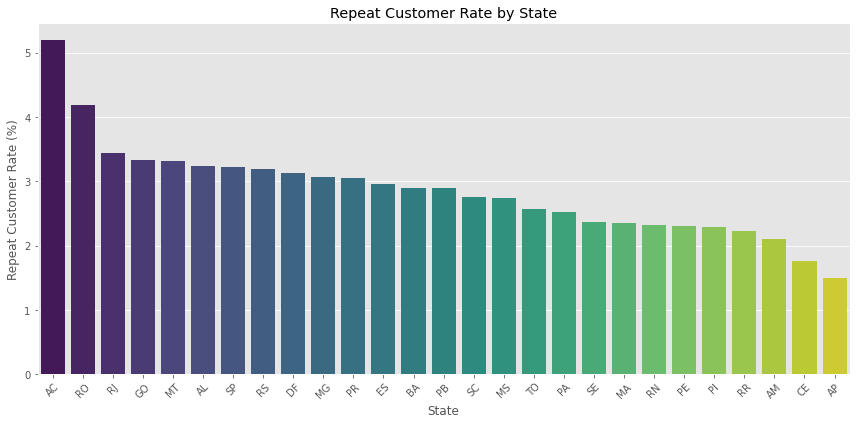

In [13]:
#Repeat Customer Rate by State

repeat_rate_state = (
    df.groupby("customer_state")["repeat_customer"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=repeat_rate_state.index,
    y=repeat_rate_state.values,
    palette="viridis"
)
plt.title("Repeat Customer Rate by State")
plt.xlabel("State")
plt.ylabel("Repeat Customer Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

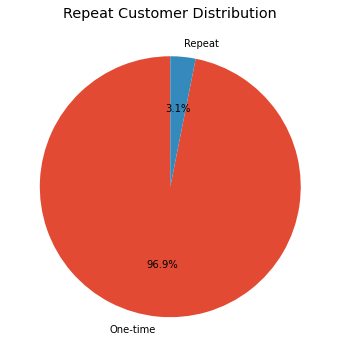

In [14]:
#Repeat Customer Distribution
repeat_counts = df["repeat_customer"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    repeat_counts,
    labels=["One-time", "Repeat"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Repeat Customer Distribution")
plt.show()

##### Overall Business Summary
1) Olist has a large customer base (96K+) and has generated R$15.8 million in revenue, indicating strong market presence.

2) Customers are generally satisfied, with an average review score of 4.08/5, and orders are typically delivered earlier than the estimated delivery date.

3) However, the repeat customer rate of just 3.12% suggests that customer retention is low, making loyalty programs and personalized marketing key opportunities for future growth.